# Music Dataset EDA - Lakh MIDI Dataset

This notebook performs Exploratory Data Analysis (EDA) and visualization on the Lakh MIDI dataset to understand its structure and characteristics.

In [1]:
import os
import json
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mido
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define dataset paths
dataset_dir = Path(r"C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI")
tar_file = dataset_dir / "lmd_full.tar.gz"
extract_dir = dataset_dir / "lmd_full_extracted"

print(f"Dataset Directory: {dataset_dir}")
print(f"Tar File Exists: {tar_file.exists()}")
print(f"Tar File Size: {tar_file.stat().st_size / (1024**3):.2f} GB" if tar_file.exists() else "N/A")

Dataset Directory: C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI
Tar File Exists: True
Tar File Size: 1.65 GB


In [3]:
# Extract a sample of MIDI files for analysis
sample_dir = dataset_dir / "sample_midi_files"
sample_dir.mkdir(exist_ok=True)

midi_files_list = []
sample_size = 500  # Number of files to extract for initial analysis

print(f"Extracting {sample_size} sample MIDI files...")

if tar_file.exists():
    with tarfile.open(tar_file, 'r:gz') as tar:
        # Get all MIDI files in the archive
        all_members = [m for m in tar.getmembers() if m.name.endswith('.mid') or m.name.endswith('.midi')]
        print(f"Total MIDI files in archive: {len(all_members)}")
        
        # Extract a sample with proper error handling and path management
        extracted_count = 0
        for i, member in enumerate(all_members):
            if extracted_count >= sample_size:
                break
                
            try:
                # Create a simpler filename to avoid Windows path length issues
                original_name = os.path.basename(member.name)
                new_filename = f"midi_{extracted_count:04d}_{original_name}"
                target_path = sample_dir / new_filename
                
                # Extract the file content and save with new name
                file_obj = tar.extractfile(member)
                if file_obj:
                    with open(target_path, 'wb') as f:
                        f.write(file_obj.read())
                    
                    midi_files_list.append(target_path)
                    extracted_count += 1
                    
                    if extracted_count % 100 == 0:
                        print(f"Extracted {extracted_count} files...")
                        
            except Exception as e:
                print(f"Skipping file {member.name}: {str(e)[:100]}...")
                continue
        
        print(f"\nSuccessfully extracted {extracted_count} MIDI files to {sample_dir}")
else:
    print("Tar file not found!")

Extracting 500 sample MIDI files...
Total MIDI files in archive: 178561
Extracted 100 files...
Extracted 200 files...
Extracted 300 files...
Extracted 400 files...
Extracted 500 files...

Successfully extracted 500 MIDI files to C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI\sample_midi_files


In [4]:
# Find all extracted MIDI files
def find_midi_files(directory):
    """Recursively find all MIDI files in a directory"""
    midi_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.mid') or file.endswith('.midi'):
                midi_files.append(os.path.join(root, file))
    return midi_files

# Get list of MIDI files
if sample_dir.exists():
    midi_files = find_midi_files(sample_dir)
    print(f"Found {len(midi_files)} MIDI files in sample directory")
else:
    midi_files = []
    print("Sample directory not found!")

Found 1451 MIDI files in sample directory


In [5]:
# Function to extract MIDI file features
def analyze_midi_file(midi_path):
    """Extract features from a MIDI file"""
    try:
        mid = mido.MidiFile(midi_path)
        
        # Basic information
        info = {
            'filename': os.path.basename(midi_path),
            'duration': mid.length,
            'num_tracks': len(mid.tracks),
            'ticks_per_beat': mid.ticks_per_beat,
            'type': mid.type,
        }
        
        # Count messages
        note_on_count = 0
        note_off_count = 0
        program_changes = []
        tempos = []
        time_signatures = []
        notes = []
        velocities = []
        
        for track in mid.tracks:
            for msg in track:
                if msg.type == 'note_on' and msg.velocity > 0:
                    note_on_count += 1
                    notes.append(msg.note)
                    velocities.append(msg.velocity)
                elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
                    note_off_count += 1
                elif msg.type == 'program_change':
                    program_changes.append(msg.program)
                elif msg.type == 'set_tempo':
                    tempos.append(msg.tempo)
                elif msg.type == 'time_signature':
                    time_signatures.append(f"{msg.numerator}/{msg.denominator}")
        
        info['note_count'] = note_on_count
        info['num_instruments'] = len(set(program_changes))
        info['instruments'] = list(set(program_changes))
        info['avg_tempo'] = np.mean(tempos) if tempos else None
        info['time_signatures'] = list(set(time_signatures))
        info['min_note'] = min(notes) if notes else None
        info['max_note'] = max(notes) if notes else None
        info['avg_velocity'] = np.mean(velocities) if velocities else None
        info['note_range'] = max(notes) - min(notes) if notes else None
        
        return info
    except Exception as e:
        return {'filename': os.path.basename(midi_path), 'error': str(e)}

# Analyze sample of MIDI files
print("Analyzing MIDI files...")
midi_data = []

# Analyze a subset for faster processing
analyze_count = min(100, len(midi_files))
for i, midi_file in enumerate(midi_files[:analyze_count]):
    info = analyze_midi_file(midi_file)
    midi_data.append(info)
    if (i + 1) % 20 == 0:
        print(f"Analyzed {i + 1}/{analyze_count} files...")

# Create DataFrame
df_midi = pd.DataFrame(midi_data)
df_midi = df_midi[df_midi['error'].isna() if 'error' in df_midi.columns else [True] * len(df_midi)]

print(f"\nSuccessfully analyzed {len(df_midi)} MIDI files")
print("\nDataFrame shape:", df_midi.shape)
print("\nFirst few rows:")
df_midi.head()

Analyzing MIDI files...
Analyzed 20/100 files...
Analyzed 40/100 files...
Analyzed 60/100 files...
Analyzed 80/100 files...
Analyzed 100/100 files...

Successfully analyzed 95 MIDI files

DataFrame shape: (95, 15)

First few rows:


,filename,duration,num_tracks,ticks_per_beat,type,note_count,num_instruments,instruments,avg_tempo,time_signatures,min_note,max_note,avg_velocity,note_range,error
0,midi_0000.mid,189.465293,1.0,480.0,0.0,7037.0,10.0,"[0, 33, 66, 1, 109, 52, 84, 119, 28, 30]",556759.245283,[4/4],26.0,83.0,85.257354,57.0,NaN
1,midi_0000_f8b9a90823dd6af25ac67eaf8fef6a43.mid,189.465293,1.0,480.0,0.0,7037.0,10.0,"[0, 33, 66, 1, 109, 52, 84, 119, 28, 30]",556759.245283,[4/4],26.0,83.0,85.257354,57.0,NaN
2,midi_0001.mid,234.432856,1.0,384.0,0.0,6941.0,9.0,"[0, 121, 37, 106, 11, 50, 53, 87, 89]",461482.000000,[4/4],0.0,105.0,78.555828,105.0,NaN
3,midi_0001_f85a225a881d7e97643c2dc4e3a8fe9a.mid,234.432856,1.0,384.0,0.0,6941.0,9.0,"[0, 121, 37, 106, 11, 50, 53, 87, 89]",461482.000000,[4/4],0.0,105.0,78.555828,105.0,NaN
4,midi_0002.mid,230.372107,13.0,480.0,1.0,5278.0,9.0,"[32, 0, 73, 9, 11, 48, 49, 56, 57]",337548.000000,"[4/4, 3/4]",27.0,106.0,91.246305,79.0,NaN


In [6]:
# Display basic statistics
print("=" * 80)
print("LAKH MIDI DATASET - BASIC STATISTICS")
print("=" * 80)

print("\n📊 Dataset Overview:")
print(f"   Total files analyzed: {len(df_midi)}")
print(f"   Dataset columns: {list(df_midi.columns)}")

print("\n📝 Descriptive Statistics:")
df_midi[['duration', 'num_tracks', 'note_count', 'num_instruments', 'avg_velocity', 'note_range']].describe()

LAKH MIDI DATASET - BASIC STATISTICS

📊 Dataset Overview:
   Total files analyzed: 95
   Dataset columns: ['filename', 'duration', 'num_tracks', 'ticks_per_beat', 'type', 'note_count', 'num_instruments', 'instruments', 'avg_tempo', 'time_signatures', 'min_note', 'max_note', 'avg_velocity', 'note_range', 'error']

📝 Descriptive Statistics:


,duration,num_tracks,note_count,num_instruments,avg_velocity,note_range
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,222.899555,9.389474,4773.021053,6.021053,88.041429,57.431579
std,168.071922,8.860977,5697.423591,4.010568,16.556240,17.731840
min,13.521120,1.000000,128.000000,0.000000,46.356484,22.000000
25%,137.468560,1.500000,1295.000000,2.000000,77.801466,42.000000
50%,201.675993,9.000000,3418.000000,6.000000,86.861933,59.000000
75%,256.108189,14.000000,6485.000000,9.000000,100.000000,64.000000
max,866.662322,31.000000,29130.000000,15.000000,113.487353,105.000000


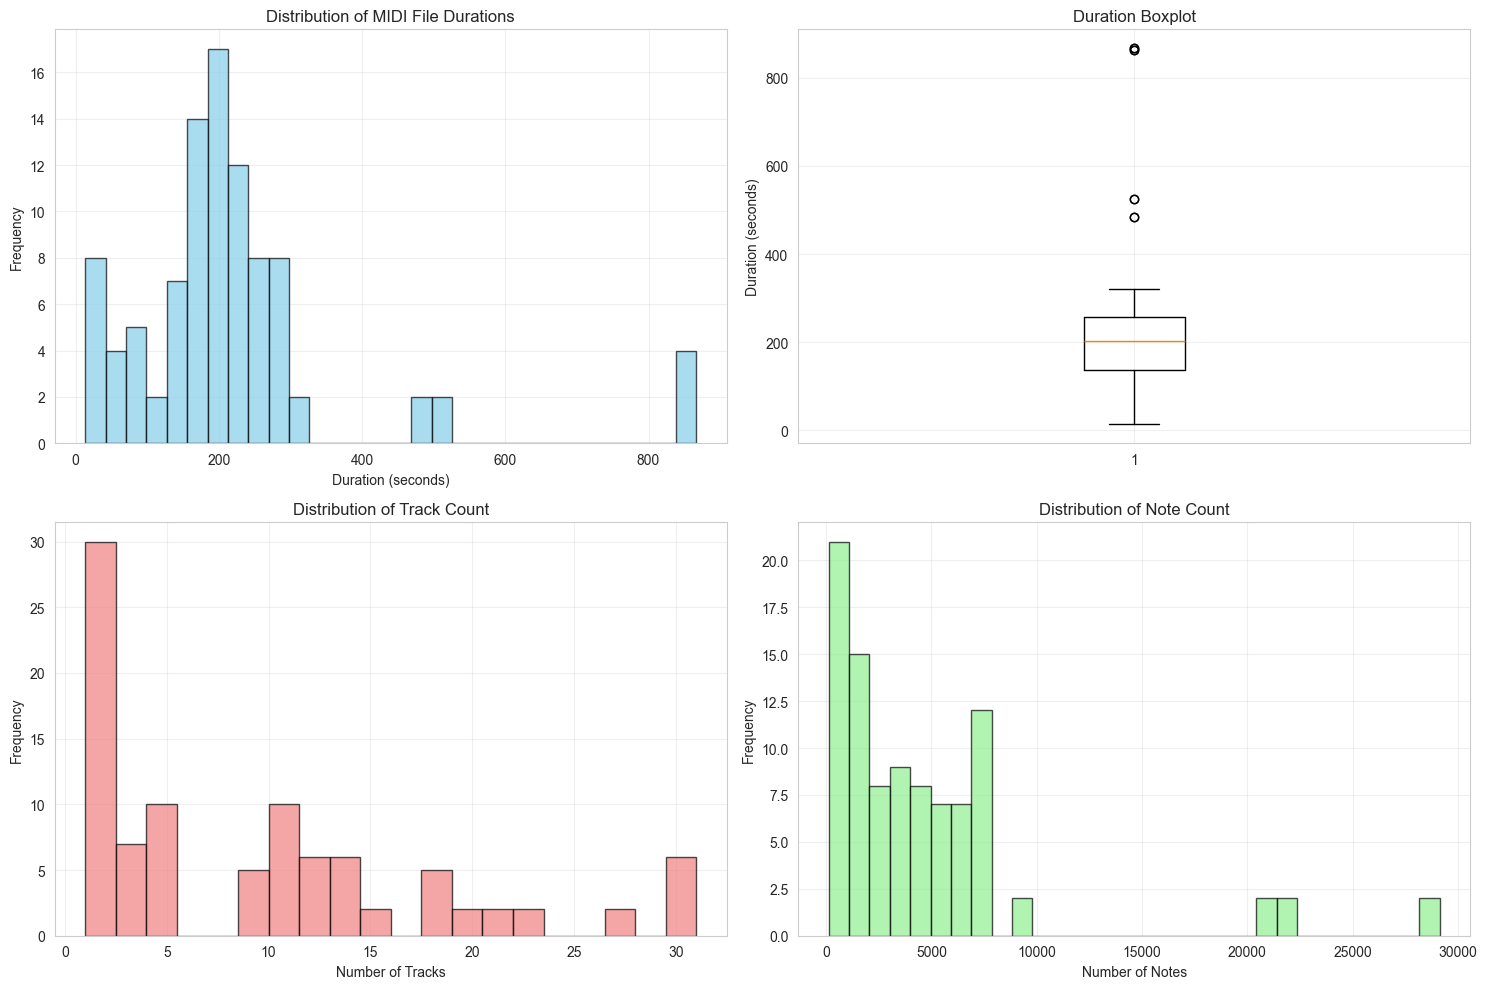

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Duration distribution
axes[0, 0].hist(df_midi['duration'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of MIDI File Durations')
axes[0, 0].grid(True, alpha=0.3)

# Duration boxplot
axes[0, 1].boxplot(df_midi['duration'])
axes[0, 1].set_ylabel('Duration (seconds)')
axes[0, 1].set_title('Duration Boxplot')
axes[0, 1].grid(True, alpha=0.3)

# Number of tracks distribution
axes[1, 0].hist(df_midi['num_tracks'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Tracks')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Track Count')
axes[1, 0].grid(True, alpha=0.3)

# Note count distribution
axes[1, 1].hist(df_midi['note_count'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Notes')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Note Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

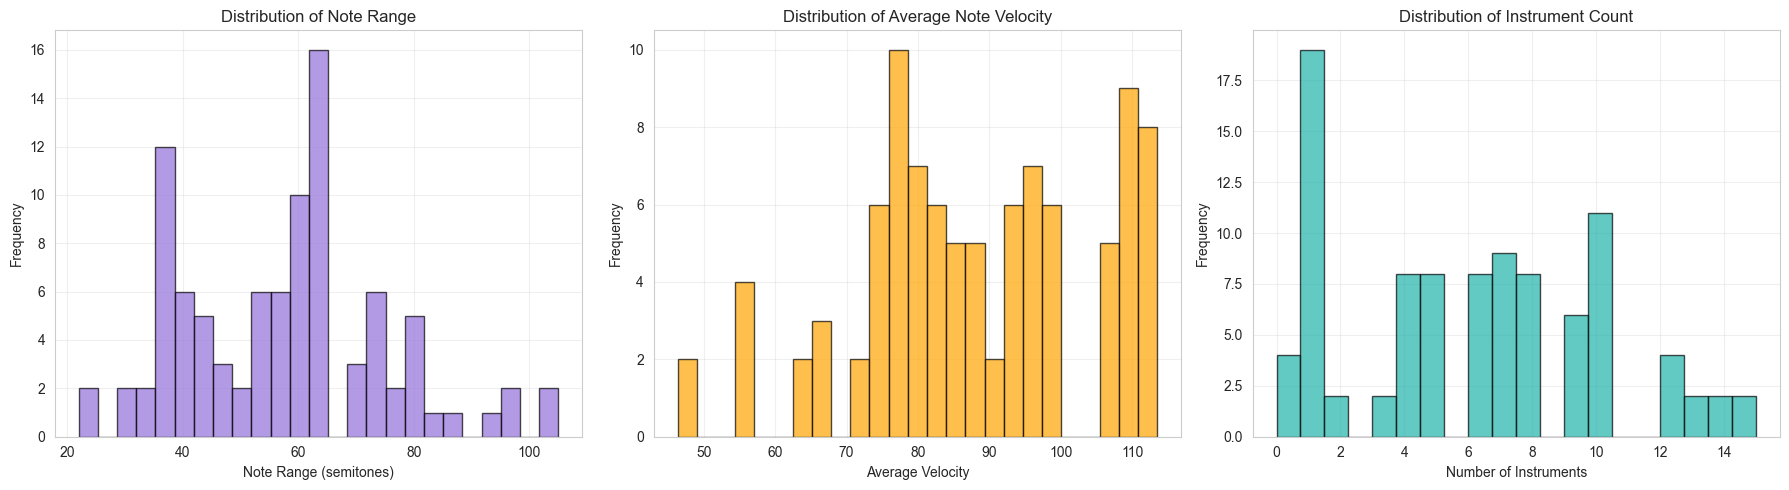

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Note range distribution
axes[0].hist(df_midi['note_range'].dropna(), bins=25, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Note Range (semitones)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Note Range')
axes[0].grid(True, alpha=0.3)

# Average velocity distribution
axes[1].hist(df_midi['avg_velocity'].dropna(), bins=25, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Average Velocity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Average Note Velocity')
axes[1].grid(True, alpha=0.3)

# Number of instruments distribution
axes[2].hist(df_midi['num_instruments'], bins=20, color='lightseagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Number of Instruments')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Instrument Count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

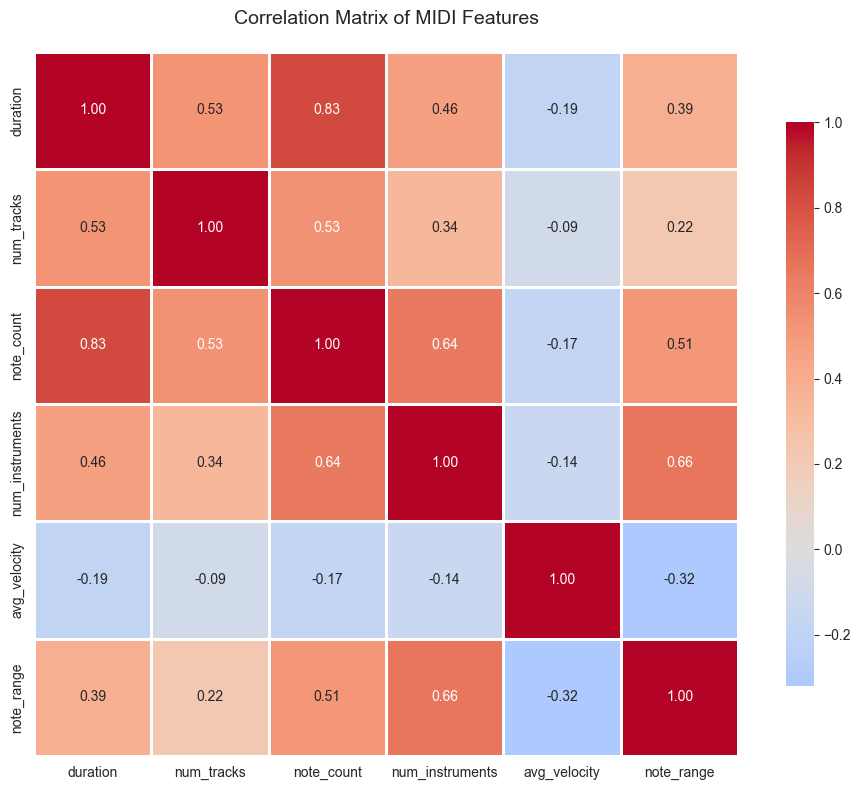

In [9]:
# Correlation heatmap
numeric_cols = ['duration', 'num_tracks', 'note_count', 'num_instruments', 'avg_velocity', 'note_range']
correlation_matrix = df_midi[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of MIDI Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

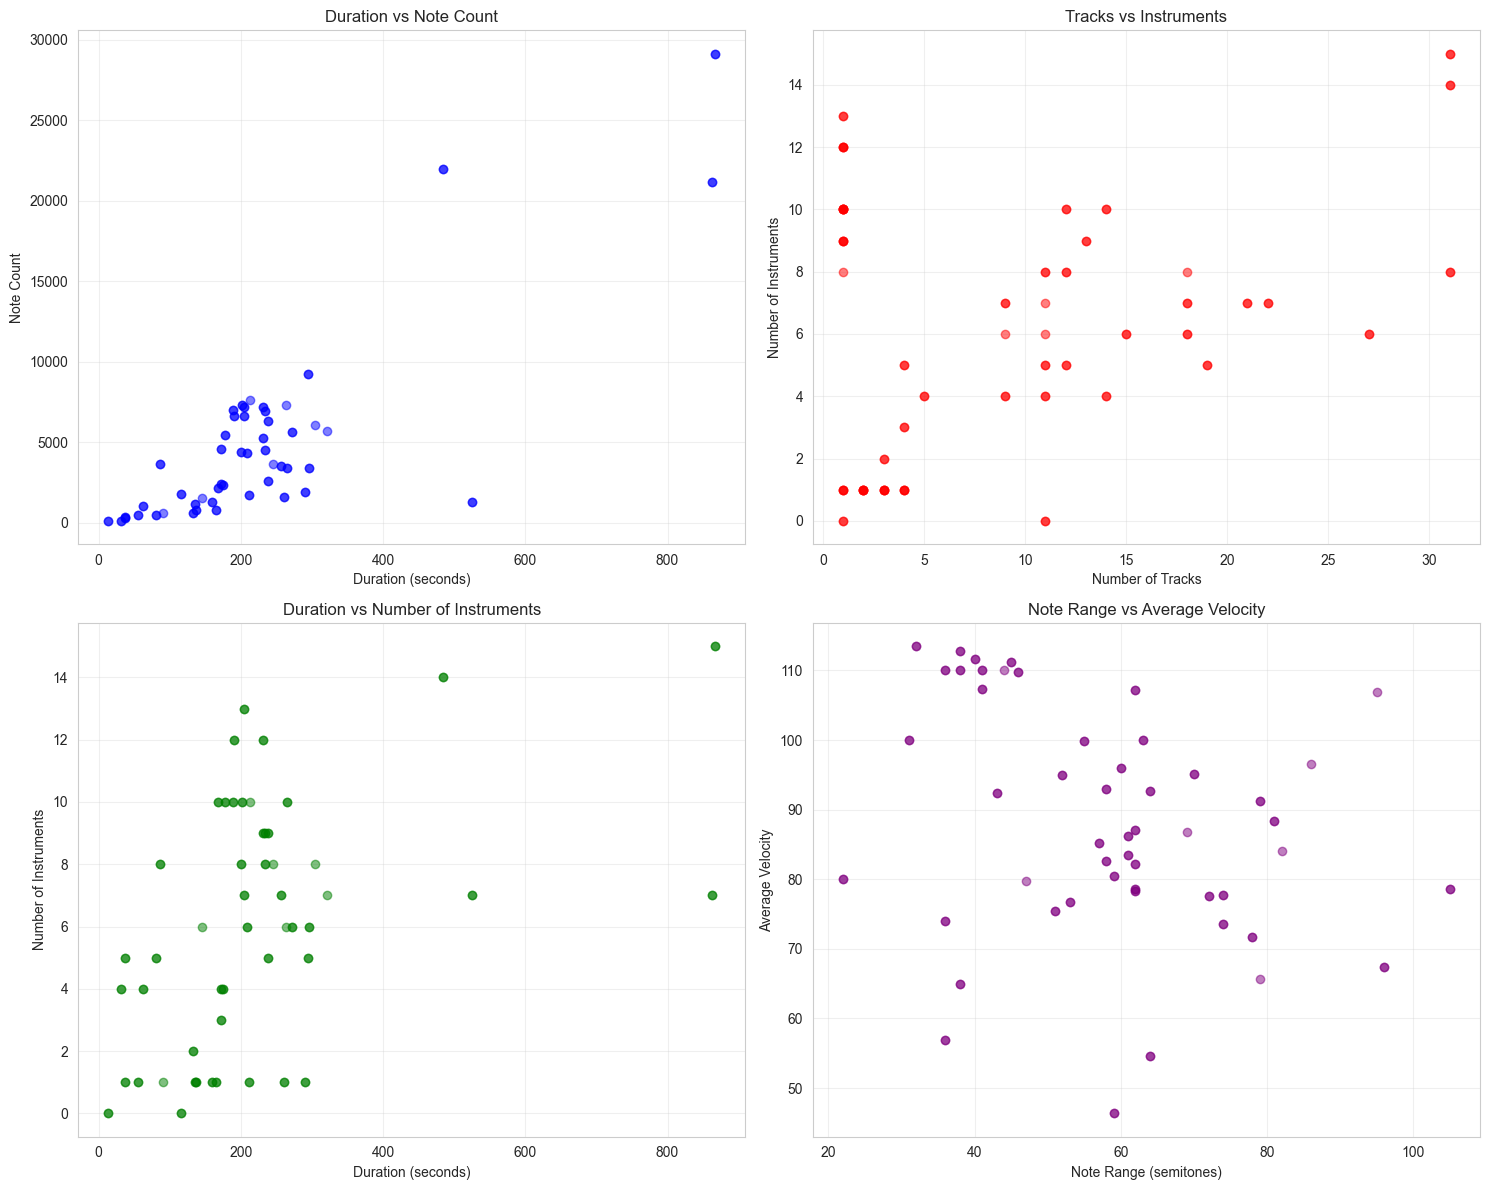

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Duration vs Note Count
axes[0, 0].scatter(df_midi['duration'], df_midi['note_count'], alpha=0.5, c='blue')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Note Count')
axes[0, 0].set_title('Duration vs Note Count')
axes[0, 0].grid(True, alpha=0.3)

# Number of Tracks vs Number of Instruments
axes[0, 1].scatter(df_midi['num_tracks'], df_midi['num_instruments'], alpha=0.5, c='red')
axes[0, 1].set_xlabel('Number of Tracks')
axes[0, 1].set_ylabel('Number of Instruments')
axes[0, 1].set_title('Tracks vs Instruments')
axes[0, 1].grid(True, alpha=0.3)

# Duration vs Number of Instruments
axes[1, 0].scatter(df_midi['duration'], df_midi['num_instruments'], alpha=0.5, c='green')
axes[1, 0].set_xlabel('Duration (seconds)')
axes[1, 0].set_ylabel('Number of Instruments')
axes[1, 0].set_title('Duration vs Number of Instruments')
axes[1, 0].grid(True, alpha=0.3)

# Note Range vs Average Velocity
axes[1, 1].scatter(df_midi['note_range'], df_midi['avg_velocity'], alpha=0.5, c='purple')
axes[1, 1].set_xlabel('Note Range (semitones)')
axes[1, 1].set_ylabel('Average Velocity')
axes[1, 1].set_title('Note Range vs Average Velocity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

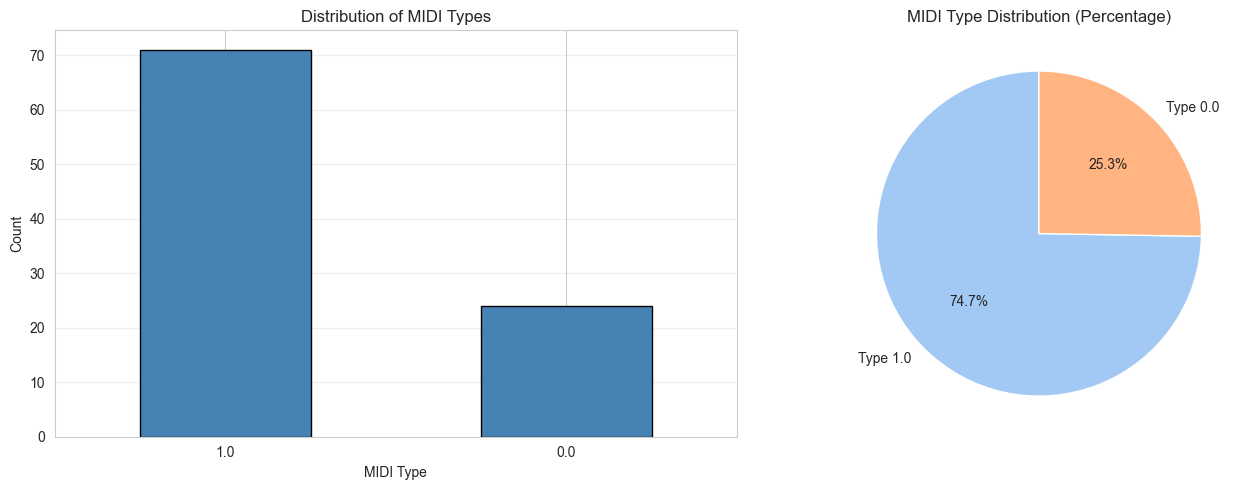


MIDI Type Descriptions:
  Type 0: Single track (all events in one track)
  Type 1: Multiple tracks, synchronous (played together)
  Type 2: Multiple tracks, asynchronous (independent sequences)


In [11]:
# MIDI type distribution
midi_types = df_midi['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
midi_types.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('MIDI Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of MIDI Types')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(midi_types.values, labels=[f'Type {t}' for t in midi_types.index], 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('MIDI Type Distribution (Percentage)')

plt.tight_layout()
plt.show()

print("\nMIDI Type Descriptions:")
print("  Type 0: Single track (all events in one track)")
print("  Type 1: Multiple tracks, synchronous (played together)")
print("  Type 2: Multiple tracks, asynchronous (independent sequences)")

In [12]:
# General MIDI Program names (simplified)
GM_PROGRAMS = {
    0: "Acoustic Grand Piano", 1: "Bright Acoustic Piano", 2: "Electric Grand Piano",
    3: "Honky-tonk Piano", 4: "Electric Piano 1", 5: "Electric Piano 2",
    6: "Harpsichord", 7: "Clavinet", 8: "Celesta", 9: "Glockenspiel",
    10: "Music Box", 11: "Vibraphone", 12: "Marimba", 13: "Xylophone",
    14: "Tubular Bells", 15: "Dulcimer", 16: "Drawbar Organ", 17: "Percussive Organ",
    18: "Rock Organ", 19: "Church Organ", 20: "Reed Organ", 21: "Accordion",
    22: "Harmonica", 23: "Tango Accordion", 24: "Acoustic Guitar (nylon)",
    25: "Acoustic Guitar (steel)", 26: "Electric Guitar (jazz)", 27: "Electric Guitar (clean)",
    28: "Electric Guitar (muted)", 29: "Overdriven Guitar", 30: "Distortion Guitar",
    31: "Guitar Harmonics", 32: "Acoustic Bass", 33: "Electric Bass (finger)",
    34: "Electric Bass (pick)", 35: "Fretless Bass", 36: "Slap Bass 1",
    37: "Slap Bass 2", 38: "Synth Bass 1", 39: "Synth Bass 2",
    40: "Violin", 48: "String Ensemble 1", 56: "Trumpet", 64: "Soprano Sax",
    73: "Flute", 80: "Lead 1 (square)", 88: "Pad 1 (new age)", 96: "FX 1 (rain)",
    104: "Sitar", 112: "Tinkle Bell", 120: "Guitar Fret Noise", 127: "Gunshot"
}

# Collect all instruments from all files
all_instruments = []
for instruments in df_midi['instruments']:
    if isinstance(instruments, list):
        all_instruments.extend(instruments)

# Count instrument occurrences
instrument_counts = Counter(all_instruments)
top_instruments = instrument_counts.most_common(20)

# Create DataFrame for visualization
instrument_df = pd.DataFrame(top_instruments, columns=['Program', 'Count'])
instrument_df['Instrument Name'] = instrument_df['Program'].apply(
    lambda x: GM_PROGRAMS.get(x, f"Program {x}")
)

print("Top 20 Most Common Instruments:")
print(instrument_df.to_string(index=False))

Top 20 Most Common Instruments:
 Program  Count         Instrument Name
       0     53    Acoustic Grand Piano
      48     34       String Ensemble 1
      33     22  Electric Bass (finger)
      30     17       Distortion Guitar
      24     16 Acoustic Guitar (nylon)
      32     15           Acoustic Bass
      25     14 Acoustic Guitar (steel)
      35     14           Fretless Bass
       1     13   Bright Acoustic Piano
      57     13              Program 57
      27     13 Electric Guitar (clean)
      52     12              Program 52
      11     12              Vibraphone
      50     12              Program 50
      49     12              Program 49
      65     12              Program 65
      60     11              Program 60
      73     10                   Flute
      29     10       Overdriven Guitar
      56      9                 Trumpet


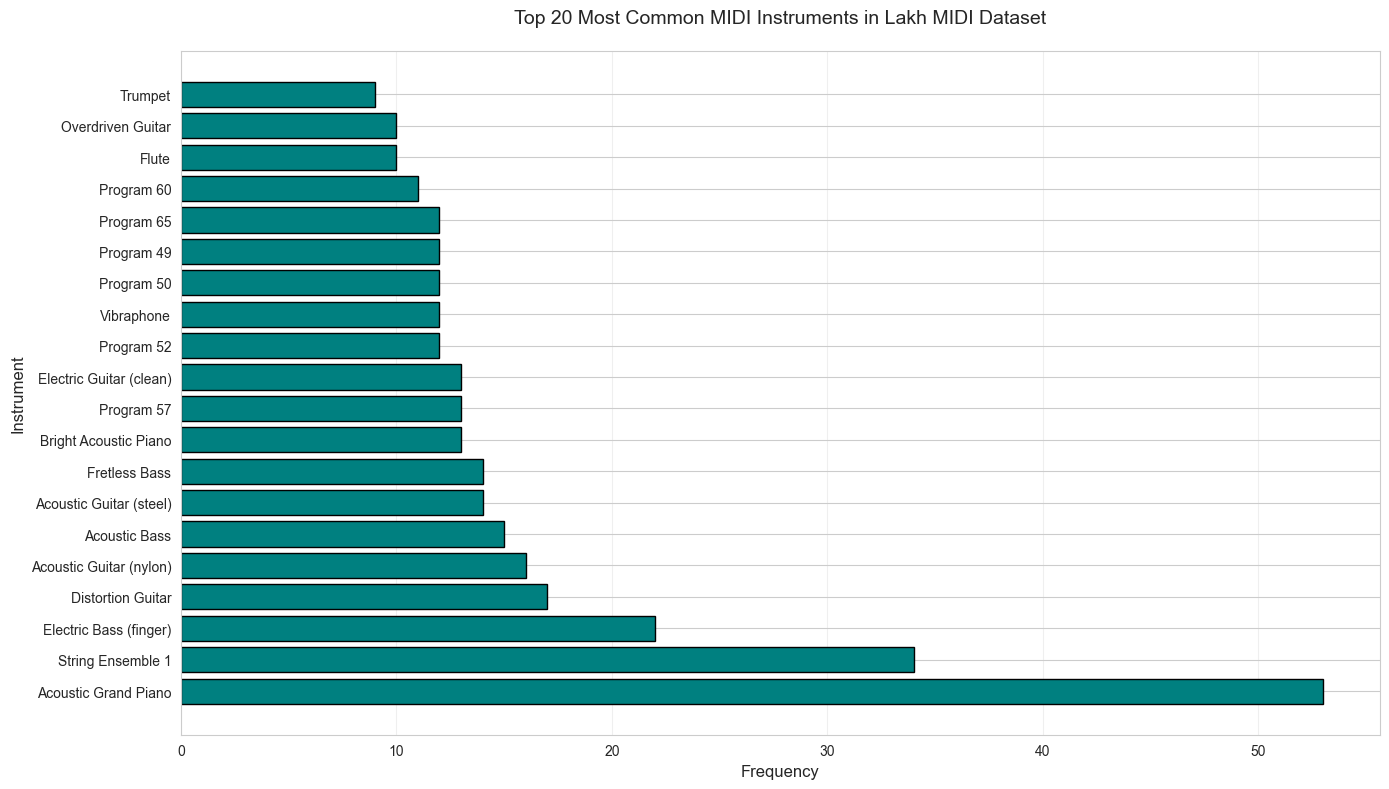

In [13]:
# Visualize top instruments
plt.figure(figsize=(14, 8))
plt.barh(range(len(instrument_df)), instrument_df['Count'], color='teal', edgecolor='black')
plt.yticks(range(len(instrument_df)), instrument_df['Instrument Name'], fontsize=10)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Instrument', fontsize=12)
plt.title('Top 20 Most Common MIDI Instruments in Lakh MIDI Dataset', fontsize=14, pad=20)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [14]:
# Select a random MIDI file for detailed analysis
if len(midi_files) > 0:
    sample_midi = midi_files[np.random.randint(0, len(midi_files))]
    print(f"Analyzing: {os.path.basename(sample_midi)}\n")
    
    mid = mido.MidiFile(sample_midi)
    
    print(f"Type: {mid.type}")
    print(f"Ticks per beat: {mid.ticks_per_beat}")
    print(f"Duration: {mid.length:.2f} seconds")
    print(f"Number of tracks: {len(mid.tracks)}\n")
    
    print("=" * 80)
    print("Track Information:")
    print("=" * 80)
    
    for i, track in enumerate(mid.tracks):
        print(f"\nTrack {i}: {track.name if track.name else 'Unnamed'}")
        print(f"  Messages: {len(track)}")
        
        # Count message types
        msg_types = Counter([msg.type for msg in track])
        print(f"  Message types: {dict(msg_types)}")
        
        # Get instruments in this track
        instruments = [msg.program for msg in track if msg.type == 'program_change']
        if instruments:
            print(f"  Instruments: {[GM_PROGRAMS.get(inst, f'Program {inst}') for inst in set(instruments)]}")
else:
    print("No MIDI files available for analysis.")

Analyzing: fce799f1fe5e469de84cf6d5e47f5fd9.mid

Type: 0
Ticks per beat: 96
Duration: 95.75 seconds
Number of tracks: 1

Track Information:

Track 0: Unnamed
  Messages: 6999
  Message types: {'midi_port': 3, 'sysex': 2, 'time_signature': 1, 'key_signature': 1, 'set_tempo': 1, 'marker': 2, 'lyrics': 14, 'control_change': 74, 'program_change': 8, 'note_on': 6892, 'end_of_track': 1}
  Instruments: ['Program 65', 'Fretless Bass', 'Program 71', 'Celesta', 'Glockenspiel', 'Program 57', 'Program 61']


In [15]:
print("=" * 80)
print("LAKH MIDI DATASET - KEY INSIGHTS")
print("=" * 80)

print("\n📌 Dataset Characteristics:")
print(f"   • Sample size analyzed: {len(df_midi)} files")
print(f"   • Average duration: {df_midi['duration'].mean():.2f} seconds")
print(f"   • Average note count: {df_midi['note_count'].mean():.0f} notes")
print(f"   • Average tracks per file: {df_midi['num_tracks'].mean():.1f}")
print(f"   • Average instruments per file: {df_midi['num_instruments'].mean():.1f}")

print("\n🎵 Musical Properties:")
print(f"   • Average note range: {df_midi['note_range'].mean():.1f} semitones")
print(f"   • Average velocity: {df_midi['avg_velocity'].mean():.1f}")
print(f"   • Min note (overall): {df_midi['min_note'].min():.0f}")
print(f"   • Max note (overall): {df_midi['max_note'].max():.0f}")

print("\n📊 MIDI Types:")
for midi_type, count in df_midi['type'].value_counts().items():
    print(f"   • Type {midi_type}: {count} files ({count/len(df_midi)*100:.1f}%)")

print("\n🎹 Top 5 Instruments:")
for i, (program, count) in enumerate(top_instruments[:5], 1):
    inst_name = GM_PROGRAMS.get(program, f"Program {program}")
    print(f"   {i}. {inst_name}: {count} occurrences")

print("\n✅ Dataset is ready for further analysis and music generation tasks!")
print("=" * 80)

LAKH MIDI DATASET - KEY INSIGHTS

📌 Dataset Characteristics:
   • Sample size analyzed: 95 files
   • Average duration: 222.90 seconds
   • Average note count: 4773 notes
   • Average tracks per file: 9.4
   • Average instruments per file: 6.0

🎵 Musical Properties:
   • Average note range: 57.4 semitones
   • Average velocity: 88.0
   • Min note (overall): 0
   • Max note (overall): 123

📊 MIDI Types:
   • Type 1.0: 71 files (74.7%)
   • Type 0.0: 24 files (25.3%)

🎹 Top 5 Instruments:
   1. Acoustic Grand Piano: 53 occurrences
   2. String Ensemble 1: 34 occurrences
   3. Electric Bass (finger): 22 occurrences
   4. Distortion Guitar: 17 occurrences
   5. Acoustic Guitar (nylon): 16 occurrences

✅ Dataset is ready for further analysis and music generation tasks!


In [16]:
# Save the analyzed data to CSV for future reference
output_dir = Path(r"C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI")
output_file = output_dir / "lakh_midi_analysis.csv"

df_midi.to_csv(output_file, index=False)
print(f"✅ Analysis saved to: {output_file}")

# Also save instrument statistics
instrument_df.to_csv(output_dir / "instrument_statistics.csv", index=False)
print(f"✅ Instrument statistics saved to: {output_dir / 'instrument_statistics.csv'}")

✅ Analysis saved to: C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI\lakh_midi_analysis.csv
✅ Instrument statistics saved to: C:\Users\porip\Documents\Pouria Ar\PouriaEdu\University2\Master Thesis\Code\Dataset\Lakh MIDI\instrument_statistics.csv


In [17]:
# Initialize pygame for MIDI playback
import pygame
import time

pygame.mixer.init()

def play_midi(midi_path, duration=30):
    """
    Play a MIDI file using pygame
    
    Args:
        midi_path: Path to MIDI file
        duration: Maximum playback duration in seconds (default 30s)
    """
    try:
        pygame.mixer.music.load(midi_path)
        pygame.mixer.music.play()
        
        print(f"🎵 Now playing: {os.path.basename(midi_path)}")
        print(f"   Duration will be limited to {duration} seconds")
        print(f"   Press 'Stop MIDI' button or wait for completion")
        
        # Play for specified duration or until song ends
        start_time = time.time()
        while pygame.mixer.music.get_busy() and (time.time() - start_time) < duration:
            time.sleep(0.1)
        
        pygame.mixer.music.stop()
        print("✅ Playback complete!")
        
    except Exception as e:
        print(f"❌ Error playing MIDI: {e}")

def stop_midi():
    """Stop currently playing MIDI"""
    pygame.mixer.music.stop()
    print("⏹️ Playback stopped!")

print("✅ MIDI player initialized!")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
✅ MIDI player initialized!


In [18]:
# Play a random MIDI file from the dataset
if len(midi_files) > 0:
    random_midi = np.random.choice(midi_files)
    
    # Show file info
    file_info = df_midi[df_midi['filename'] == os.path.basename(random_midi)]
    if not file_info.empty:
        print("📊 File Information:")
        print(f"   Filename: {file_info.iloc[0]['filename']}")
        print(f"   Duration: {file_info.iloc[0]['duration']:.2f} seconds")
        print(f"   Tracks: {file_info.iloc[0]['num_tracks']}")
        print(f"   Instruments: {file_info.iloc[0]['num_instruments']}")
        print(f"   Notes: {file_info.iloc[0]['note_count']}")
        print()
    
    # Play the file (30 seconds max)
    play_midi(random_midi, duration=30)
else:
    print("No MIDI files available!")

🎵 Now playing: midi_0230.mid
   Duration will be limited to 30 seconds
   Press 'Stop MIDI' button or wait for completion
✅ Playback complete!


In [19]:
# Display list of available MIDI files with their characteristics
print(f"Available MIDI Files ({len(midi_files)} total):\n")

# Show first 20 files with details
for i, midi_path in enumerate(midi_files[:20], 1):
    filename = os.path.basename(midi_path)
    file_info = df_midi[df_midi['filename'] == filename]
    
    if not file_info.empty:
        info = file_info.iloc[0]
        print(f"{i:2d}. {filename}")
        print(f"    Duration: {info['duration']:.1f}s | Tracks: {info['num_tracks']} | "
              f"Instruments: {info['num_instruments']} | Notes: {info['note_count']}")
    else:
        print(f"{i:2d}. {filename}")
    print()

print("\n💡 To play a specific file, use: play_midi(midi_files[index], duration=30)")
print("   Example: play_midi(midi_files[0], duration=30)")

Available MIDI Files (1451 total):

 1. midi_0000.mid
    Duration: 189.5s | Tracks: 1.0 | Instruments: 10.0 | Notes: 7037.0

 2. midi_0000_f8b9a90823dd6af25ac67eaf8fef6a43.mid
    Duration: 189.5s | Tracks: 1.0 | Instruments: 10.0 | Notes: 7037.0

 3. midi_0001.mid
    Duration: 234.4s | Tracks: 1.0 | Instruments: 9.0 | Notes: 6941.0

 4. midi_0001_f85a225a881d7e97643c2dc4e3a8fe9a.mid
    Duration: 234.4s | Tracks: 1.0 | Instruments: 9.0 | Notes: 6941.0

 5. midi_0002.mid
    Duration: 230.4s | Tracks: 13.0 | Instruments: 9.0 | Notes: 5278.0

 6. midi_0002_fdc9a30d6512b6165da48340c290a0c4.mid
    Duration: 230.4s | Tracks: 13.0 | Instruments: 9.0 | Notes: 5278.0

 7. midi_0003.mid
    Duration: 271.8s | Tracks: 15.0 | Instruments: 6.0 | Notes: 5651.0

 8. midi_0003_fee5e8ef07701433da3a79cfd9d82703.mid
    Duration: 271.8s | Tracks: 15.0 | Instruments: 6.0 | Notes: 5651.0

 9. midi_0004.mid

10. midi_0004_f2c6082099e6007dec7abbd60bcbf3b8.mid

11. midi_0005.mid
    Duration: 208.0s | Tr

In [20]:
# Play a specific file by index (change the index to try different files)
file_index = 0  # Change this number to play different files (0 to len(midi_files)-1)

if 0 <= file_index < len(midi_files):
    selected_file = midi_files[file_index]
    print(f"Playing file #{file_index + 1}:\n")
    
    # Show file info
    filename = os.path.basename(selected_file)
    file_info = df_midi[df_midi['filename'] == filename]
    if not file_info.empty:
        info = file_info.iloc[0]
        print("📊 File Details:")
        print(f"   Filename: {info['filename']}")
        print(f"   Duration: {info['duration']:.2f} seconds")
        print(f"   MIDI Type: {info['type']}")
        print(f"   Tracks: {info['num_tracks']}")
        print(f"   Instruments: {info['num_instruments']}")
        print(f"   Note Count: {info['note_count']}")
        print(f"   Note Range: {info['note_range']} semitones")
        print(f"   Avg Velocity: {info['avg_velocity']:.1f}")
        print()
    
    play_midi(selected_file, duration=30)
else:
    print(f"Invalid index! Please choose between 0 and {len(midi_files)-1}")

Playing file #1:

📊 File Details:
   Filename: midi_0000.mid
   Duration: 189.47 seconds
   MIDI Type: 0.0
   Tracks: 1.0
   Instruments: 10.0
   Note Count: 7037.0
   Note Range: 57.0 semitones
   Avg Velocity: 85.3

🎵 Now playing: midi_0000.mid
   Duration will be limited to 30 seconds
   Press 'Stop MIDI' button or wait for completion
✅ Playback complete!


In [21]:
def create_piano_roll(midi_path, max_time=30):
    """
    Create a piano roll visualization of a MIDI file
    
    Args:
        midi_path: Path to MIDI file
        max_time: Maximum time to display (seconds)
    """
    try:
        mid = mido.MidiFile(midi_path)
        
        # Collect all note events with timing
        notes = []
        current_time = 0
        
        for track in mid.tracks:
            track_time = 0
            for msg in track:
                track_time += msg.time / mid.ticks_per_beat * 0.5  # Approximate conversion
                
                if msg.type == 'note_on' and msg.velocity > 0:
                    notes.append({
                        'time': track_time,
                        'note': msg.note,
                        'velocity': msg.velocity,
                        'type': 'on'
                    })
                elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
                    notes.append({
                        'time': track_time,
                        'note': msg.note,
                        'velocity': 0,
                        'type': 'off'
                    })
        
        # Filter notes within time range
        notes = [n for n in notes if n['time'] <= max_time]
        
        if not notes:
            print("No notes found in the specified time range!")
            return
        
        # Create piano roll plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
        
        # Plot 1: Piano Roll
        note_on_dict = {}
        for note_event in notes:
            note_num = note_event['note']
            time = note_event['time']
            
            if note_event['type'] == 'on':
                note_on_dict[note_num] = time
            elif note_event['type'] == 'off' and note_num in note_on_dict:
                start_time = note_on_dict[note_num]
                duration = time - start_time
                ax1.barh(note_num, duration, left=start_time, height=0.8, 
                        color='steelblue', edgecolor='black', alpha=0.7)
                del note_on_dict[note_num]
        
        ax1.set_xlabel('Time (seconds)', fontsize=12)
        ax1.set_ylabel('MIDI Note Number', fontsize=12)
        ax1.set_title(f'Piano Roll: {os.path.basename(midi_path)}', fontsize=14, pad=15)
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, max_time)
        
        # Plot 2: Note Density Over Time
        time_bins = np.linspace(0, max_time, 50)
        note_counts = []
        
        for i in range(len(time_bins) - 1):
            count = sum(1 for n in notes if time_bins[i] <= n['time'] < time_bins[i+1] and n['type'] == 'on')
            note_counts.append(count)
        
        ax2.plot(time_bins[:-1], note_counts, color='darkgreen', linewidth=2)
        ax2.fill_between(time_bins[:-1], note_counts, alpha=0.3, color='lightgreen')
        ax2.set_xlabel('Time (seconds)', fontsize=12)
        ax2.set_ylabel('Note Density', fontsize=12)
        ax2.set_title('Note Density Over Time', fontsize=14, pad=15)
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, max_time)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\n📊 Visualization Statistics:")
        print(f"   Total notes displayed: {len([n for n in notes if n['type'] == 'on'])}")
        print(f"   Time range: 0 - {max_time} seconds")
        print(f"   Note range: {min(n['note'] for n in notes)} - {max(n['note'] for n in notes)}")
        
    except Exception as e:
        print(f"❌ Error creating piano roll: {e}")

print("✅ Piano roll function ready!")

✅ Piano roll function ready!


Visualizing file #1: midi_0000.mid



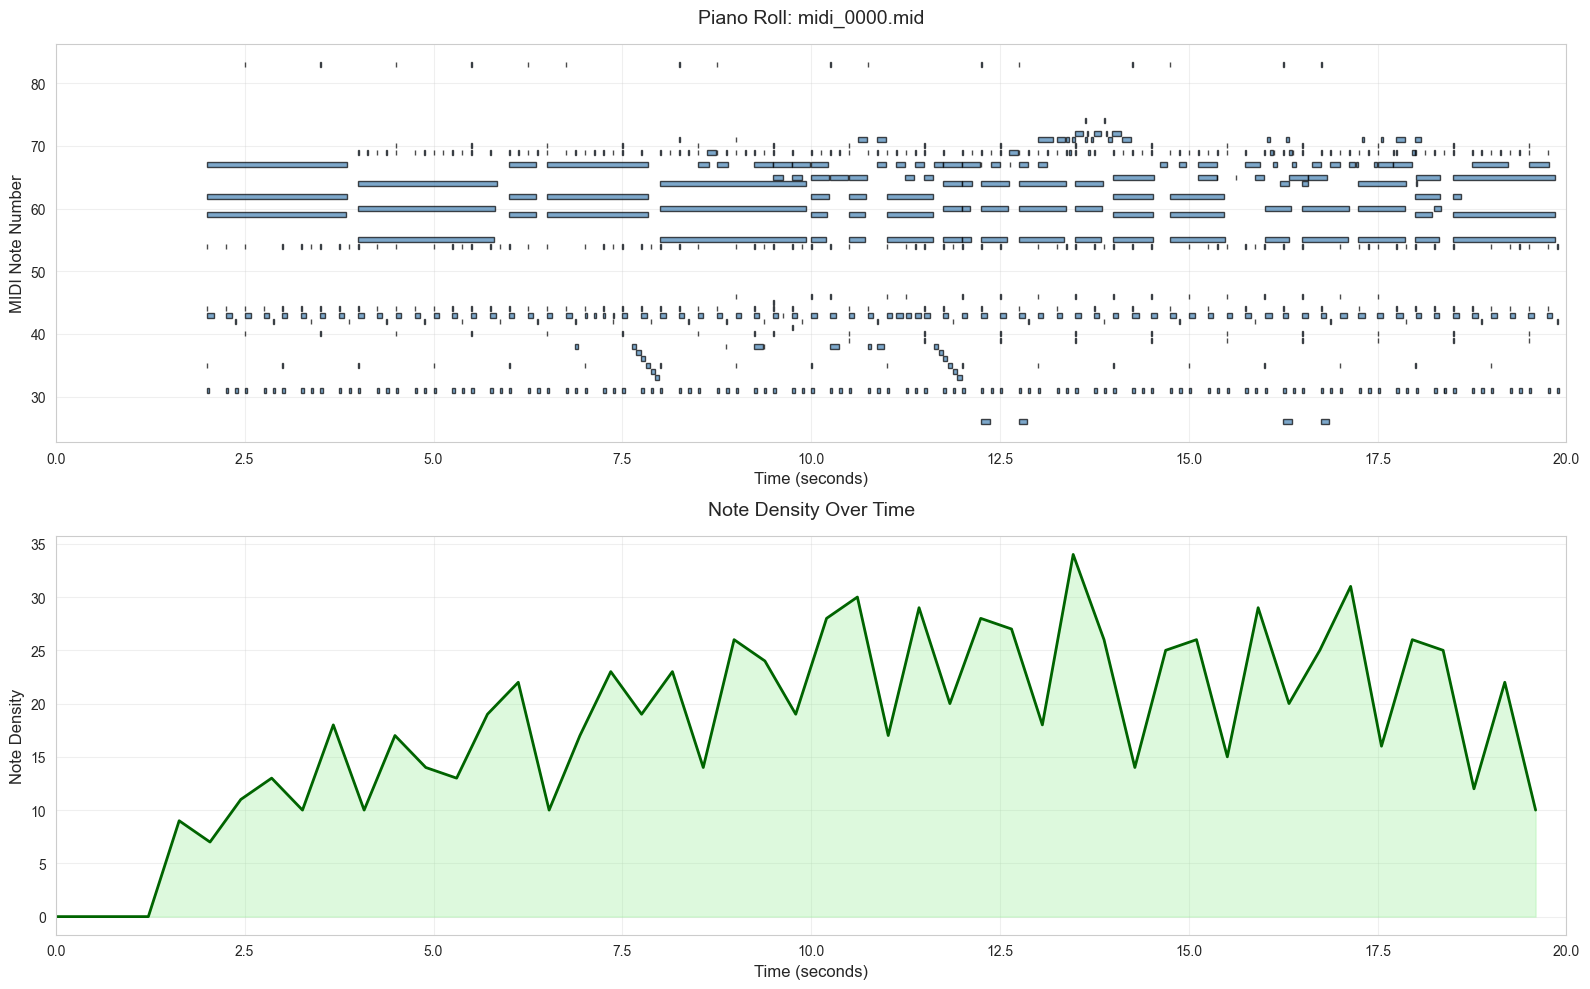


📊 Visualization Statistics:
   Total notes displayed: 891
   Time range: 0 - 20 seconds
   Note range: 26 - 83
Number of Tracks: 1.0


In [22]:
# Visualize a MIDI file as piano roll
if len(midi_files) > 0:
    # Choose a file to visualize
    viz_index = 0  # Change this to visualize different files
    
    if 0 <= viz_index < len(midi_files):
        selected_file = midi_files[viz_index]
        print(f"Visualizing file #{viz_index + 1}: {os.path.basename(selected_file)}\n")
        
        create_piano_roll(selected_file, max_time=20)  # Show first 20 seconds
        print("Number of Tracks:", df_midi.loc[df_midi['filename'] == os.path.basename(selected_file), 'num_tracks'].values[0])
    else:
        print(f"Invalid index! Choose between 0 and {len(midi_files)-1}")
else:
    print("No MIDI files available!")

In [23]:
# Compare files with different characteristics
print("=" * 80)
print("COMPARING DIFFERENT MIDI FILES")
print("=" * 80)

# Find files with different characteristics
short_file = df_midi.nsmallest(1, 'duration').iloc[0] if len(df_midi) > 0 else None
long_file = df_midi.nlargest(1, 'duration').iloc[0] if len(df_midi) > 0 else None
complex_file = df_midi.nlargest(1, 'num_instruments').iloc[0] if len(df_midi) > 0 else None
simple_file = df_midi.nsmallest(1, 'num_instruments').iloc[0] if len(df_midi) > 0 else None

comparisons = [
    ("Shortest File", short_file),
    ("Longest File", long_file),
    ("Most Complex (instruments)", complex_file),
    ("Simplest (instruments)", simple_file)
]

for label, file_info in comparisons:
    if file_info is not None:
        print(f"\n{'='*40}")
        print(f"{label}:")
        print(f"{'='*40}")
        print(f"   Filename: {file_info['filename']}")
        print(f"   Duration: {file_info['duration']:.2f}s")
        print(f"   Tracks: {file_info['num_tracks']}")
        print(f"   Instruments: {file_info['num_instruments']}")
        print(f"   Notes: {file_info['note_count']}")
        print(f"   Note Range: {file_info['note_range']} semitones")

print(f"\n{'='*80}")
print("💡 TIP: To play any of these files, find it in the midi_files list and use:")
print("   play_midi(midi_files[index], duration=30)")
print("="*80)

COMPARING DIFFERENT MIDI FILES

Shortest File:
   Filename: midi_0023.mid
   Duration: 13.52s
   Tracks: 1.0
   Instruments: 0.0
   Notes: 128.0
   Note Range: 22.0 semitones

Longest File:
   Filename: midi_0009.mid
   Duration: 866.66s
   Tracks: 31.0
   Instruments: 15.0
   Notes: 29130.0
   Note Range: 96.0 semitones

Most Complex (instruments):
   Filename: midi_0009.mid
   Duration: 866.66s
   Tracks: 31.0
   Instruments: 15.0
   Notes: 29130.0
   Note Range: 96.0 semitones

Simplest (instruments):
   Filename: midi_0015.mid
   Duration: 115.62s
   Tracks: 11.0
   Instruments: 0.0
   Notes: 1809.0
   Note Range: 64.0 semitones

💡 TIP: To play any of these files, find it in the midi_files list and use:
   play_midi(midi_files[index], duration=30)


In [24]:
# Stop currently playing MIDI
stop_midi()

⏹️ Playback stopped!
